# Concordance IVFPQ vs SCimilarity
SCimilarity uses TileDB IVF_FLAT index which provides exact vector similarity search. IVFPQ quantizes the vectors and then performs an approximate lookup based on partitions.

In [34]:
from pathlib import Path
from typing import Tuple
from collections import Counter
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import torch

from scimilarity import CellAnnotation
from scimilarity.utils import align_dataset, lognorm_counts

from ivfpq import IVFPQ

In [35]:
n_cells = 100
k_neighbors = 50

In [36]:
# Load test data
adata = anndata.read_h5ad("data/GSE136831_subsample.h5ad")
print(f"Loaded test data shape: {adata.shape}")

# Subset the AnnData object
# Using .obs_names ensures that if the AnnData object's internal
# integer indexing changes, we still get the correct cells.
np.random.seed(42)
random_indices = np.random.choice(
    # Select from obs names (more robust than indices if adata is manipulated)
    adata.obs_names.values,
    size=n_cells,
    replace=False,  # Ensure unique cells
)
adata = adata[random_indices, :].copy()  # Use .copy() to avoid view issues
print(f"Selected subset shape: {adata.shape}")

Loaded test data shape: (50000, 44942)
Selected subset shape: (100, 44942)


## Compute SCimilarity Neighbors

In [37]:
def get_scimilarity_predictions(
    adata: anndata.AnnData, model_path: Path, k_neighbors: int = 50
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict]:
    """
    Get cell type predictions using SCimilarity.

    Returns:
        embeddings: Cell embeddings [n_cells, embedding_dim]
        predictions: Cell type predictions [n_cells]
        nn_idxs: Indices of nearest neighbors [n_cells, k_neighbors]
        nn_dists: Distances to nearest neighbors [n_cells, k_neighbors]
        stats: Statistics about the predictions
    """
    # Load SCimilarity model
    cell_annotation = CellAnnotation(model_path, use_gpu=False)

    # Align and normalize
    adata_aligned = align_dataset(adata, cell_annotation.gene_order)
    adata_normalized = lognorm_counts(adata_aligned)

    # Get embeddings
    embeddings = cell_annotation.get_embeddings(adata_normalized.X)

    # Get predictions
    predictions, nn_idxs, nn_dists, stats = cell_annotation.get_predictions_knn(
        embeddings, k=k_neighbors, disable_progress=True, weighting=True
    )

    return embeddings, predictions, nn_idxs, nn_dists, stats


embeddings, sc_predictions, sc_idxs, sc_dists, sc_stats = get_scimilarity_predictions(
    adata, "data/models/scimilarity/model_v1.1", k_neighbors=k_neighbors
)

## Compute IVFPQ Neighbors

In [38]:
def get_ivfpq_predictions(
    embeddings: np.ndarray,
    model_path: Path,
    reference_labels: pd.DataFrame,
    k_neighbors: int = 50,
    n_partitions_search: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Get cell type predictions using IVFPQ with batched processing.

    Returns:
        predictions: Predicted cell type labels [n_cells]
        nn_idxs: Indices of nearest neighbors [n_cells, k_neighbors]
        nn_dists: Distances to nearest neighbors [n_cells, k_neighbors]
        nn_labels: Labels of nearest neighbors [n_cells, k_neighbors]
    """

    ivf = IVFPQ.load(model_path)

    predictions = []
    nn_idxs = []
    nn_dists = []
    nn_labels = []

    for embedding in embeddings:
        # Convert to torch tensor
        query_vector = torch.from_numpy(embedding).float()

        # Search using IVFPQ
        vector_ids, distances = ivf.search(
            query_vector=query_vector,
            model_path=model_path,
            n_probe=n_partitions_search,
        )

        # Convert to numpy arrays and limit to k_neighbors
        nn_idxs.append(np.array(vector_ids[:k_neighbors]))
        nn_dists.append(np.array(distances[:k_neighbors]))

        # Get labels for nearest neighbors
        neighbor_labels = []
        for vec_id in vector_ids[:k_neighbors]:  # Ensure we only use k neighbors
            if vec_id < len(reference_labels):
                # Get the "prediction" column from reference labels
                label = reference_labels.iloc[vec_id]["prediction"]
                neighbor_labels.append(label)

        nn_labels.append(neighbor_labels)

        # Vote for most common label (simple majority voting)
        if neighbor_labels:
            label_counts = Counter(neighbor_labels)
            predicted_label = label_counts.most_common(1)[0][0]
        else:
            predicted_label = "Unknown"

        predictions.append(predicted_label)

    print(f"  Processed {len(embeddings)} cells")

    # Stack arrays to create proper 2D numpy arrays
    return (
        np.array(predictions),
        np.vstack(nn_idxs),  # Creates [n_cells, k_neighbors] array
        np.vstack(nn_dists),  # Creates [n_cells, k_neighbors] array
        np.array(nn_labels, dtype=object),
    )


reference_labels = pd.read_parquet("data/references/scimilarity/labels.parquet")

ivfpq_predictions, ivfpq_idxs, ivfpq_dists, ivfpq_labels = get_ivfpq_predictions(
    embeddings,
    Path("public/models/scimilarity/ivfpq"),
    reference_labels=reference_labels,
    k_neighbors=k_neighbors,
    n_partitions_search=4,
)

  Processed 100 cells


In [39]:
print(sc_predictions)
print(ivfpq_predictions)

0        natural killer cell
1        alveolar macrophage
2                  mast cell
3              ciliated cell
4        alveolar macrophage
               ...          
95          endothelial cell
96       alveolar macrophage
97    non-classical monocyte
98                fibroblast
99                    T cell
Length: 100, dtype: object
['natural killer cell' 'alveolar macrophage' 'mast cell' 'ciliated cell'
 'alveolar macrophage' 'alveolar macrophage' 'T cell' 'macrophage'
 'alveolar macrophage' 'macrophage' 'T cell' 'alveolar macrophage'
 'classical monocyte' 'alveolar macrophage' 'ciliated cell' 'myeloid cell'
 'native cell' 'T cell' 'myeloid cell' 'macrophage' 'alveolar macrophage'
 'type II pneumocyte' 'T cell' 'macrophage' 'alveolar macrophage'
 'memory B cell' 'alveolar macrophage' 'plasma cell' 'alveolar macrophage'
 'alveolar macrophage' 'alveolar macrophage' 'T cell'
 'alveolar macrophage' 'alveolar macrophage' 'classical monocyte'
 'myeloid cell' 'myeloid cell' 'matur

In [40]:
# Make sure it appears we're operating in the same index space
print(sc_idxs[0])
print(ivfpq_idxs[0])

[7242532 7238156 6608711 7243047 7233237 7235371 7218585 7226773 7269752
 3329079 7271784 3327980 3333117 7241075 2876894 7272084 3312669 7279710
 7247086 3171003 7237776 3308742 7236457 7232045 7278686 7250288 2890572
 7266040 3325207 2888602 3324201 7233386 7261462 6645240 2874821 7624702
 7228269 2888924 7272302 7230558 7831490 7253521 2889520 7254079 7264647
 6592152 7279490 3341528 7266697 7227790]
[7242532 7235371 7238156 7243047 7233237 7218585 7226773 7241075 7272084
 7237776 7232045 7278686 7257542 7269470 7247086 7269752 7250288 3329079
 7258339 7807043 7271784 7236457 7270407 7253521 7244204 7233386 3308742
 7807844 7279710 7266697 7264431 7254079 7250251 7228269 7269251 7264647
 7244346 7235953 7270261 3341528 6592152 7222540 2874821 7266040 7254467
 7272302 7230558 7235046 7227667 7279246]


In [41]:
# Check what labels are at the SCimilarity indices
print("Labels at SCimilarity indices (first 10):")
for idx in sc_idxs[0][:10]:
    if idx < len(reference_labels):
        print(f"  Index {idx}: {reference_labels.iloc[idx]['prediction']}")
    else:
        print(f"  Index {idx}: OUT OF BOUNDS")

print("\nLabels at IVFPQ indices (first 10):")
for idx in ivfpq_idxs[0][:10]:
    if idx < len(reference_labels):
        print(f"  Index {idx}: {reference_labels.iloc[idx]['prediction']}")
    else:
        print(f"  Index {idx}: OUT OF BOUNDS")

Labels at SCimilarity indices (first 10):
  Index 7242532: natural killer cell
  Index 7238156: natural killer cell
  Index 6608711: natural killer cell
  Index 7243047: natural killer cell
  Index 7233237: natural killer cell
  Index 7235371: natural killer cell
  Index 7218585: natural killer cell
  Index 7226773: natural killer cell
  Index 7269752: natural killer cell
  Index 3329079: natural killer cell

Labels at IVFPQ indices (first 10):
  Index 7242532: natural killer cell
  Index 7235371: natural killer cell
  Index 7238156: natural killer cell
  Index 7243047: natural killer cell
  Index 7233237: natural killer cell
  Index 7218585: natural killer cell
  Index 7226773: natural killer cell
  Index 7241075: natural killer cell
  Index 7272084: T cell
  Index 7237776: natural killer cell


## Distance Distortion vs. Recall

SCimilarity (get_predictions_knn): Uses cosine distance via hnswlib
IVFPQ (PQDistance): Uses squared Euclidean distance

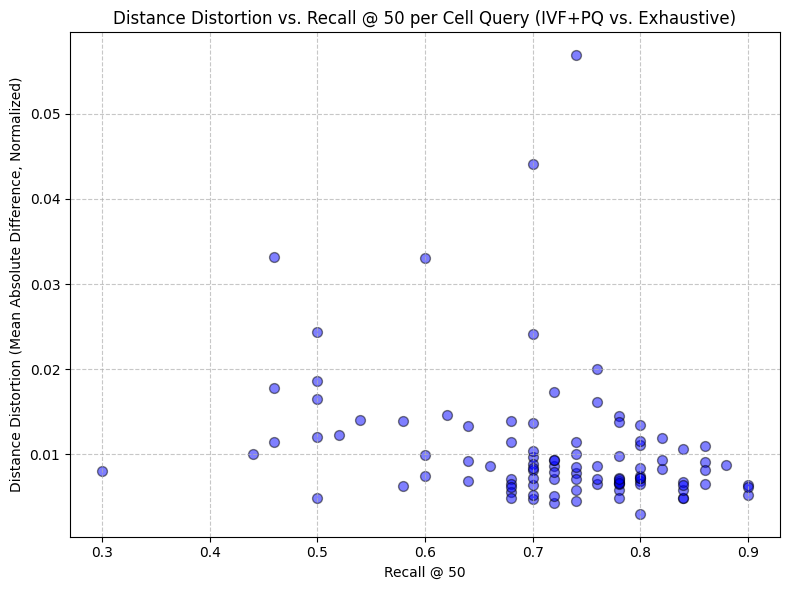

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume sc_dists, sc_idxs, ivfpq_dists, ivfpq_idxs are numpy arrays [n_cells, k_neighbors]
# Normalize distances to [0, 1] to compare cosine and squared Euclidean metrics
sc_dists_normalized = (sc_dists - np.min(sc_dists)) / (
    np.max(sc_dists) - np.min(sc_dists) + 1e-10
)
ivfpq_dists_normalized = (ivfpq_dists - np.min(ivfpq_dists)) / (
    np.max(ivfpq_dists) - np.min(ivfpq_dists) + 1e-10
)


# Calculate Recall @ k
def calculate_recall(sc_idxs, ivfpq_idxs, k):
    recall = []
    for i in range(sc_idxs.shape[0]):
        true_set = set(sc_idxs[i, :k])
        approx_set = set(ivfpq_idxs[i, :k])
        recall.append(len(true_set & approx_set) / k)
    return np.array(recall)


# Calculate distance distortion (mean absolute difference of normalized distances for matching indices)
def calculate_distortion(sc_dists_norm, sc_idxs, ivfpq_dists_norm, ivfpq_idxs, k):
    distortion = []
    for i in range(sc_idxs.shape[0]):
        # Find common indices between true and approximate neighbors
        common_indices = set(sc_idxs[i, :k]) & set(ivfpq_idxs[i, :k])
        if len(common_indices) == 0:
            # If no common indices, use mean absolute difference across all k neighbors
            distortion.append(
                np.mean(np.abs(sc_dists_norm[i, :k] - ivfpq_dists_norm[i, :k]))
            )
        else:
            # Get distances for common indices
            sc_dist_subset = []
            ivfpq_dist_subset = []
            for idx in common_indices:
                sc_pos = np.where(sc_idxs[i, :k] == idx)[0]
                ivfpq_pos = np.where(ivfpq_idxs[i, :k] == idx)[0]
                if len(sc_pos) > 0 and len(ivfpq_pos) > 0:
                    sc_dist_subset.append(sc_dists_norm[i, sc_pos[0]])
                    ivfpq_dist_subset.append(ivfpq_dists_norm[i, ivfpq_pos[0]])
            if len(sc_dist_subset) > 0:
                distortion.append(
                    np.mean(
                        np.abs(np.array(sc_dist_subset) - np.array(ivfpq_dist_subset))
                    )
                )
            else:
                distortion.append(
                    np.mean(np.abs(sc_dists_norm[i, :k] - ivfpq_dists_norm[i, :k]))
                )
    return np.array(distortion)


# Compute metrics for k (default to 10 or max neighbors)
k = min(50, sc_dists.shape[1])
recall_k = calculate_recall(sc_idxs, ivfpq_idxs, k)
distortion = calculate_distortion(
    sc_dists_normalized, sc_idxs, ivfpq_dists_normalized, ivfpq_idxs, k
)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(recall_k, distortion, alpha=0.5, s=50, c="blue", edgecolors="k")
plt.xlabel(f"Recall @ {k}")
plt.ylabel("Distance Distortion (Mean Absolute Difference, Normalized)")
plt.title(
    f"Distance Distortion vs. Recall @ {k} per Cell Query (IVF+PQ vs. Exhaustive)"
)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

# Save and show plot
# plt.savefig("distortion_vs_recall_ivfpq.png")
plt.show()